# Generating surface plots of a single cortical hemisphere

This notebook is a tutorial for generating visualisations of a single cortical surface hemisphere using `plotting_pyvista.plot_surf`.

In [1]:
from importlib.resources import files
import matplotlib.pyplot as plt
import nibabel as nib
from neuromodes.io import fetch_surf
from neuromodes import EigenSolver
from nsbutils.utils import unmask
from nsbutils.plotting_pyvista import plot_surf

We start by loading the necessary surfaces, and medial masks.

In [2]:
species = 'human'
den = "32k"

surf_lh_data, medmask_lh = fetch_surf(density=den, hemi="L", species=species)
surf_lh = {"vertices": surf_lh_data.v, "faces": surf_lh_data.t}

We can calculate geometrice eigenmodes to use as data to plot on the surfaces.

In [3]:
solver_lh = EigenSolver(surf_lh, medmask_lh)
solver_lh.solve(n_modes=100)

modes_unmasked = unmask(solver_lh.emodes, medmask_lh)

Now we can plot the first non-constant eigenmode as an interactive plot. If you spin the surface around you'll notice that the medial wall is grey. This is handled by `rois` where any vertex labelled with `0` is greyed-out.

In [4]:
surfs = {"lh": surf_lh}
data = {"lh": modes_unmasked[:, 1]}
rois = {"lh": medmask_lh}

p = plot_surf(surfs, data=data, rois=rois, zoom=1, cmap="RdBu")
p.enable_anti_aliasing("ssaa")
p.show()

Widget(value='<iframe src="http://localhost:60028/index.html?ui=P_0x1390eadd0_0&reconnect=auto" class="pyvista…

We can optionally plot the mesh edges, add a colobar, and adjust the size.

In [5]:
p = plot_surf(
    surfs, data=data, rois=rois, zoom=1, cmap="RdBu", mesh_edges=True, cbar=True, size=(800, 600)
)
p.show()

Widget(value='<iframe src="http://localhost:60028/index.html?ui=P_0x1390ebbb0_1&reconnect=auto" class="pyvista…

We can also plot multiple views. Note that the order of the views is determined by how they are ordered in views.

In [6]:
p = plot_surf(
    surfs, data=data, rois=rois, cmap="RdBu", views=["lateral", "medial"]
)
p.show()

Widget(value='<iframe src="http://localhost:60028/index.html?ui=P_0x1390eb280_2&reconnect=auto" class="pyvista…

We can also plot a parcellation by inputting it into rois and setting roi_outline=True. Zeros will again be masked out.

In [7]:
parc_lh_data = files('nsbutils').parent / 'docs' / 'tutorials' / 'tutorial_data' / 'Q1-Q6_RelatedParcellation210.L.CorticalAreas_dil_Colors.32k_fs_LR.label.gii'
parc_lh = nib.load(parc_lh_data).darrays[0].data.astype(int)
rois_parc = {"lh": parc_lh}

p = plot_surf(
    surfs, data=data, rois=rois_parc, cmap="RdBu", views=["lateral"], roi_outlines=True
)
p.show()

Widget(value='<iframe src="http://localhost:60028/index.html?ui=P_0x1390eb370_3&reconnect=auto" class="pyvista…

Alternatively if `data` has the same number of elements as the number of unique values in `rois`, data is plotted ROI-wise.

In [8]:
p = plot_surf(
    surfs, data=rois_parc, rois=rois_parc, cmap="tab20", views=["lateral"], roi_outlines=True
)
p.show()

Widget(value='<iframe src="http://localhost:60028/index.html?ui=P_0x1390ea890_4&reconnect=auto" class="pyvista…

We can plot multiple maps by redifining surfs["lh"] to be a 2D array. Note that size adjusts the size of each subplot.

In [9]:
mode_ids = [1,2,3,99]
data_multi = {"lh": modes_unmasked[:, mode_ids]}

p = plot_surf(
    surfs, data=data_multi, rois=rois_parc, zoom=1, cmap="RdBu", views=["lateral"], size=(300, 250)
)
p.show()

Widget(value='<iframe src="http://localhost:60028/index.html?ui=P_0x177ceeb00_5&reconnect=auto" class="pyvista…

So far we have only plotted the left hemisphere; however, we can plot both left and right hemispheres by setting both `"lh"` and `"rh"` key-value pairs to `surf`, `data`, and `rois`.

In [10]:
surf_rh_data, medmask_rh = fetch_surf(density=den, hemi="R", species=species)
surf_rh = {"vertices": surf_rh_data.v, "faces": surf_rh_data.t}
surfs = {"lh": surf_lh, "rh": surf_rh}
rois = {"lh": medmask_lh, "rh": medmask_rh}

solver_rh = EigenSolver(surf_rh, medmask_rh)
solver_rh.solve(n_modes=100)
data = {
    "lh": unmask(solver_lh.emodes[:, 1], medmask_lh),
    "rh": unmask(solver_rh.emodes[:, 1], medmask_rh)
}

In [11]:
p = plot_surf(
    surfs, data=data, rois=rois, zoom=1, cmap="RdBu", views=["lateral", "medial"],
)
p.show()

Widget(value='<iframe src="http://localhost:60028/index.html?ui=P_0x107f4beb0_6&reconnect=auto" class="pyvista…

We can then add multiple views and change `layout_indiv` to adjust how the different views are arranged.

In [12]:
p1 = plot_surf(
    surfs, data=data, rois=rois, zoom=1, cmap="RdBu", views=["lateral", "medial"],
    size=(300, 250), layout_indiv="row" 
)
p1.show()

p2 = plot_surf(
    surfs, data=data, rois=rois, zoom=1, cmap="RdBu", views=["lateral", "medial"],
    size=(300, 250), layout_indiv="grid" 
)
p2.show()   

Widget(value='<iframe src="http://localhost:60028/index.html?ui=P_0x1390eb940_7&reconnect=auto" class="pyvista…

Widget(value='<iframe src="http://localhost:60028/index.html?ui=P_0x1390eaef0_8&reconnect=auto" class="pyvista…

We can plot multiple maps (with multiple hemis and views) and define how they are globally arranged by using `layout_group`.

In [13]:
data = {
    "lh": unmask(solver_lh.emodes[:, mode_ids], medmask_lh), 
    "rh": unmask(solver_rh.emodes[:, mode_ids], medmask_rh)
}

p = plot_surf(
    surfs, data=data, rois=rois, zoom=1, cmap="RdBu", views=["lateral", "medial"],
    size=(300, 250), layout_indiv="row", layout_group="col",
)
p.show()

Widget(value='<iframe src="http://localhost:60028/index.html?ui=P_0x1390ebc10_9&reconnect=auto" class="pyvista…

plot_surf always returns a plotly figure but we can optionally pass in a matplotlib axis using the ax argument in which case the figure will be converted to a static image and inserted into the axis. We can use the scale argument to increase the resolution.

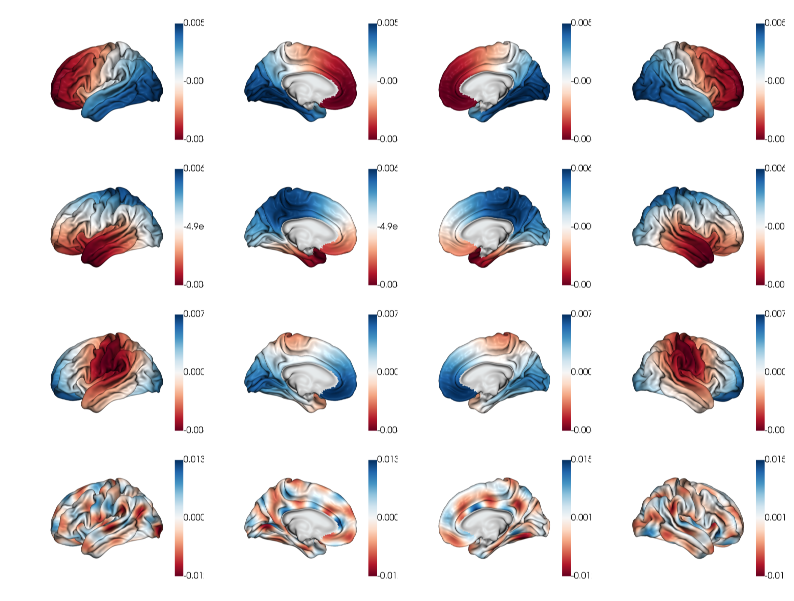

In [14]:
fig, ax = plt.subplots(figsize=(10, 10))

data = {
    "lh": unmask(solver_lh.emodes[:, mode_ids], medmask_lh), 
    "rh": unmask(solver_rh.emodes[:, mode_ids], medmask_rh)
}
p = plot_surf(
    surfs, data=data, rois=rois, zoom=1, cmap="RdBu", views=["lateral", "medial"], 
    layout_indiv="row", layout_group="col", ax=ax, cbar=True, scale=10
)

plt.show()